In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
circle = Hypersphere(1)



ModuleNotFoundError: No module named 'utils'

In [3]:
tau2 = 0.05
n_samples = 1000
rho = 1e-5

all_num_modes =  [1, 2, 3, 4]
all_sigma2s = [0.0025, 0.01, 0.05, .1, .25, .5]

all_Ms = [4,6,8,10]

NMC = 3

In [ ]:
# # hyperparameter (M, rho) selection for by crossvalidation
# print('hyperparameter (M, rho) selection for by crossvalidation\n')
# params_to_M_dict = {}; params_to_rho_dict = {}

# cv_res = {}
# for num_modes in all_num_modes:
#     G_params = {'tau2': tau2 , 'num_modes': num_modes} 
#     Theta = multimodal_sampler((n_samples,manifold_type, G_params))
#     for sigma2 in tqdm(all_sigma2s, desc = 'σ²' ):
#         X = circle.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
#         deltas = [denoiser('S1', X, M, rho, sigma2, X) for M in tqdm(all_Ms, desc = 'M ', leave= False)]
#         losses = [(circle.metric.dist_broadcast(delta, Theta) ** 2).mean() for delta in deltas]
#         params_to_M_dict.update({(num_modes, sigma2) : all_Ms[int(np.argmin(losses))]})
#         cv_res.update({(num_modes, sigma2) : losses})
#     print('Hyperparameter selection for {} modes done.'.format(num_modes))
#     # for sigma2 in all_sigma2s: print('  {},{} : {}'.format(num_modes, sigma2, params_to_M_dict[num_modes, sigma2]))




In [ ]:
# stepsize selection for by crossvalidation
M = 5
params_to_M_dict  = {(num_modes, sigma2) : M for num_modes in all_num_modes for sigma2 in all_sigma2s}


all_stepsizes = np.arange(1,10)
print('stepsize selection by crossvalidation\n')
params_to_stepsize_dict = {}
cv_res = {}
for num_modes in all_num_modes:
    G_params = {'tau2': tau2 , 'num_modes': num_modes} 
    Theta = multimodal_sampler((n_samples,manifold_type, G_params))
    for sigma2 in tqdm(all_sigma2s, desc = 'σ²' ):
        X = circle.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
        _, hat_f, hat_grad_f = density_estimate('S1', X, M, X)
        deltas = [denoiser('S1', X, M, rho, sigma2, X, stepsize = stepsize, densityIn=(hat_f, hat_grad_f)) 
                  for stepsize in tqdm(all_stepsizes, desc = 'stepsize ', leave= False)]
        losses = [(circle.metric.dist_broadcast(delta, Theta) ** 2).mean() for delta in deltas]

        params_to_stepsize_dict.update({(num_modes, sigma2) : all_stepsizes[int(np.argmin(losses))]})
        cv_res.update({(num_modes, sigma2) : losses})
    print('Stepsize selection for {} modes done.'.format(num_modes))




stepsize selection by crossvalidation



σ²: 100%|██████████| 6/6 [00:02<00:00,  2.22it/s]


Stepsize selection for 1 modes done.


σ²: 100%|██████████| 6/6 [00:02<00:00,  2.25it/s]


Stepsize selection for 2 modes done.


σ²: 100%|██████████| 6/6 [00:02<00:00,  2.22it/s]


Stepsize selection for 3 modes done.


σ²: 100%|██████████| 6/6 [00:02<00:00,  2.21it/s]

Stepsize selection for 4 modes done.


In [18]:
params_to_stepsize_dict

{(1, 0.0025): 9,
 (1, 0.01): 5,
 (1, 0.05): 4,
 (1, 0.1): 3,
 (1, 0.25): 2,
 (1, 0.5): 1,
 (2, 0.0025): 6,
 (2, 0.01): 4,
 (2, 0.05): 4,
 (2, 0.1): 3,
 (2, 0.25): 2,
 (2, 0.5): 1,
 (3, 0.0025): 5,
 (3, 0.01): 7,
 (3, 0.05): 5,
 (3, 0.1): 2,
 (3, 0.25): 1,
 (3, 0.5): 1,
 (4, 0.0025): 9,
 (4, 0.01): 9,
 (4, 0.05): 3,
 (4, 0.1): 1,
 (4, 0.25): 1,
 (4, 0.5): 1}

In [ ]:

all_records = []  # Collect all data across num_modes
for num_modes in all_num_modes:
    G_params = {'tau2': tau2 , 'num_modes': num_modes} 
    for sigma2 in all_sigma2s:
        loss_Ts, loss_Ns = [], []
        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}', leave = False ):
            Theta = multimodal_sampler((n_samples,manifold_type, G_params))
            X = circle.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
            loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()
            M, stepsize = params_to_M_dict[(num_modes, sigma2)], params_to_stepsize_dict[(num_modes,sigma2)]
            delta = denoiser('S1', X, M, rho, sigma2, X, stepsize = stepsize)
            loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean() 
            loss_Ts.append(loss_T); loss_Ns.append(loss_N)
        all_records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "sigma2": [sigma2] * NMC,
            "loss_T": loss_Ts,
            "loss_N": loss_Ns
        }))

df = pd.concat(all_records, ignore_index=True)
df_long = df.melt(
    id_vars=["num_modes", "sigma2"],
    value_vars=["loss_T", "loss_N"],
    var_name="Loss Type",
    value_name="Loss"
)
df = pd.concat(all_records, ignore_index=True)


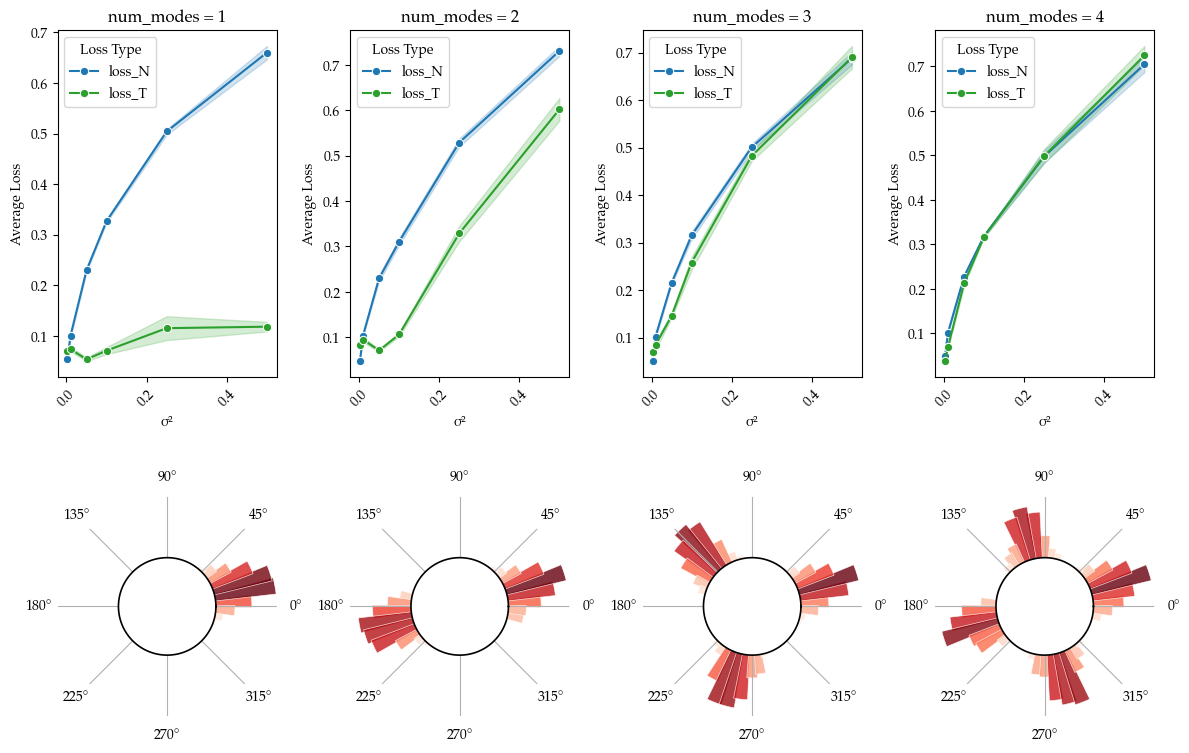

In [ ]:
fig, axs = plt.subplots(2, len(all_num_modes), figsize=(12, 8))

for idx, num_modes in enumerate(all_num_modes):
    df_subset = df_long[df_long['num_modes'] == num_modes]

    sns.lineplot(
        data=df_subset,
        x="sigma2",
        y="Loss",
        hue="Loss Type",
        hue_order=["loss_N", "loss_T"],
        palette={"loss_N": "C0", "loss_T": "C2"},
        estimator="mean",
        errorbar=("ci", 68),  # 1-sigma style band; use 95 if you prefer
        marker="o",
        ax=axs[0, idx],
    )

    axs[0, idx].set_title(f"num_modes = {num_modes}")
    axs[0, idx].set_xlabel("σ²")
    axs[0, idx].set_ylabel("Average Loss")
    axs[0, idx].tick_params(axis='x', rotation=45)
    

    axs[1, idx].remove()
    axs[1, idx] = fig.add_subplot( 2, len(all_num_modes), idx + len(all_num_modes) + 1, polar=True)

    Theta = multimodal_sampler(  n_samples, {'tau2': tau2, 'num_modes': num_modes})
    # S1_smooth_histogram( Theta, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[1, idx], 'Reds')
    S1_histogram(Theta, 50, axs[1, idx], 'Reds')

plt.tight_layout()
plt.show()

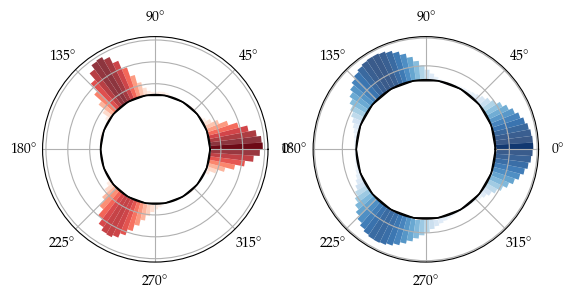

In [ ]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'})
Theta = multimodal_sampler(  n_samples, {'tau2': tau2, 'num_modes': 3})
sigma2 = 1e-2
X = circle.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

S1_smooth_histogram( Theta, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[0], 'Reds')
S1_smooth_histogram( X, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[1], 'Blues')





In [ ]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'})
Theta = multimodal_sampler(  n_samples, {'tau2': tau2, 'num_modes': 3})
sigma2 = 1e-2
X = circle.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

S1_histogram(Theta, 50, axs[0], 'Reds')
S1_histogram(X, 50, axs[1], 'Blues')
